In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Data Loading and Preprocessing

In [69]:
#Load the data
df_train = pd.read_csv('/content/pisa2009train.csv')
df_test = pd.read_csv('/content/pisa2009test.csv')

In [70]:
#Check for the Missing Value
df_train.isnull().sum()
df_train=df_train.dropna()
df_test.isnull().sum()
df_test=df_test.dropna()

In [73]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 990 entries, 0 to 1569
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   grade                  990 non-null    int64  
 1   male                   990 non-null    int64  
 2   raceeth                990 non-null    object 
 3   preschool              990 non-null    float64
 4   expectBachelors        990 non-null    float64
 5   motherHS               990 non-null    float64
 6   motherBachelors        990 non-null    float64
 7   motherWork             990 non-null    float64
 8   fatherHS               990 non-null    float64
 9   fatherBachelors        990 non-null    float64
 10  fatherWork             990 non-null    float64
 11  selfBornUS             990 non-null    float64
 12  motherBornUS           990 non-null    float64
 13  fatherBornUS           990 non-null    float64
 14  englishAtHome          990 non-null    float64
 15  computerFo

In [71]:
print(df_train.iloc[:,2].unique())

map1={}
map2={}
for i,j in enumerate(df_train.iloc[:,2].unique()):
  map1[j]=i
  map2[i]=j

['White' 'Black' 'Hispanic' 'More than one race'
 'American Indian/Alaska Native' 'Asian'
 'Native Hawaiian/Other Pacific Islander']


In [72]:
df_train_copy=df_train

# for i in range(len(df_train)):
  # df_train_copy.iloc[i,2]=map1[df_train.iloc[i,2]]

for i in range(len(df_test)):
  df_test.iloc[i,2]=int(map1[df_test.iloc[i,2]])

In [78]:
df_test['raceeth'].dtype=np.int64

AttributeError: can't set attribute 'dtype'

In [7]:
print(df_train_copy.iloc[:,2])

1       0
3       1
4       2
7       0
9       3
       ..
3655    0
3657    3
3659    0
3660    2
3662    0
Name: raceeth, Length: 2414, dtype: object


# 2. Descriptive Statistics

In [22]:
df_train_copy.loc[:,].describe()

,grade,male,preschool,expectBachelors,motherHS,motherBachelors,motherWork,fatherHS,fatherBachelors,fatherWork,...,englishAtHome,computerForSchoolwork,read30MinsADay,minutesPerWeekEnglish,studentsInEnglish,schoolHasLibrary,publicSchool,urban,schoolSize,readingScore
count,2414.000000,2414.000000,2414.000000,2414.000000,2414.000000,2414.000000,2414.000000,2414.000000,2414.000000,2414.000000,...,2414.000000,2414.000000,2414.000000,2414.000000,2414.000000,2414.000000,2414.000000,2414.000000,2414.000000,2414.000000
mean,10.126346,0.501243,0.727423,0.834300,0.896023,0.363712,0.735708,0.874068,0.348384,0.857084,...,0.881524,0.915493,0.301574,269.842999,24.561723,0.971417,0.917564,0.362883,1371.649544,517.962887
std,0.523174,0.500102,0.445377,0.371888,0.305294,0.481167,0.441047,0.331842,0.476557,0.350060,...,0.323237,0.278204,0.459036,141.331014,7.042124,0.166667,0.275084,0.480931,847.800992,89.325693
min,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,100.000000,244.480000
25%,10.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,...,1.000000,1.000000,0.000000,225.000000,20.000000,1.000000,1.000000,0.000000,712.000000,455.847500
50%,10.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,...,1.000000,1.000000,0.000000,250.000000,25.000000,1.000000,1.000000,0.000000,1233.000000,520.205000
75%,10.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,300.000000,30.000000,1.000000,1.000000,1.000000,1900.000000,581.395000
max,12.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1680.000000,75.000000,1.000000,1.000000,1.000000,6694.000000,746.000000


In [50]:
df_train_copy.loc[:,'minutesPerWeekEnglish'].describe()

,minutesPerWeekEnglish
count,2414.000000
mean,269.842999
std,141.331014
min,0.000000
25%,225.000000
50%,250.000000
75%,300.000000
max,1680.000000


# 3. Data Visualization

<ipython-input-24-066c1c0d8e13>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df_train_copy,  x='grade', y='readingScore', palette='Set2')
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to

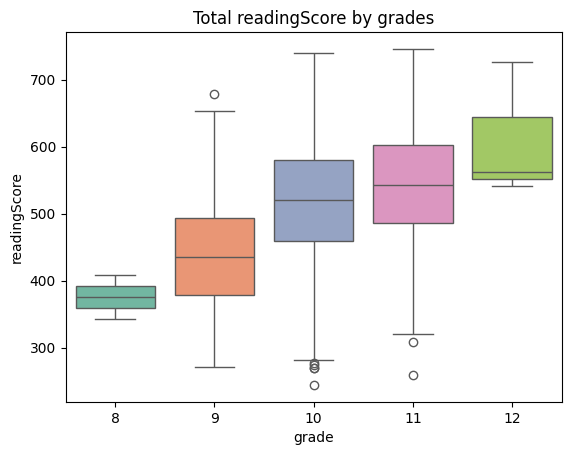

In [24]:

#Box Plot - Total bill by days
sns.boxplot(data = df_train_copy,  x='grade', y='readingScore', palette='Set2')
plt.title('Total readingScore by grades')
plt.show()


In [35]:
tp=df_train_copy[df_train_copy.iloc[:,0]==9]
print(max(tp.iloc[:,-1]))

678.24


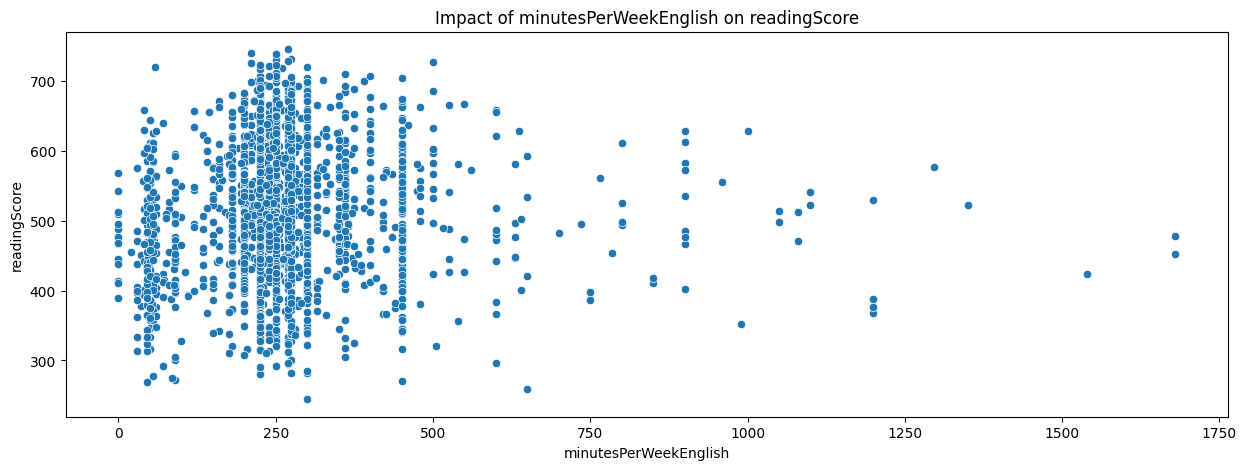

In [37]:
#Scatter Plot for Total Crashes According to Year
plt.figure(figsize=(15,5))
sns.scatterplot(x='minutesPerWeekEnglish', y= 'readingScore', data=df_train_copy)
plt.title('Impact of minutesPerWeekEnglish on readingScore')
plt.show()

# 4. Hypothesis Testing

In [10]:
from scipy import stats

# Sample data for two groups
tp=df_train_copy[df_train_copy.iloc[:,1]==0]
group1 = tp.iloc[:,-1]
tp=df_train_copy[df_train_copy.iloc[:,1]==1]
group2 = tp.iloc[:,-1]

print(len(group1), len(group2))
# Perform t-test
t_stat, p_value = stats.ttest_ind(group1, group2)

print(f'T-statistic: {t_stat}')
print(f'P-value: {p_value}')

1204 1210
T-statistic: 6.361556268672979
P-value: 2.3817969301776225e-10


t-statistic: The t-statistic tells us how many standard deviations the two group means are apart. A higher absolute value indicates a greater difference.


p-value: If the p-value is below 0.05 (for a 95% confidence level), we reject the null hypothesis.

Since the p-value (0.015) is less than 0.05, we reject the null hypothesis and conclude that the two groups' means are significantly different.

In [51]:
from scipy import stats

# Sample data for two groups
tp=df_train_copy[df_train_copy.iloc[:,9]==0]
group1 = tp.iloc[:,-1]
tp=df_train_copy[df_train_copy.iloc[:,9]==1]
group2 = tp.iloc[:,-1]

print(len(group1), len(group2))
# Perform t-test
t_stat, p_value = stats.ttest_ind(group1, group2)

print(f'T-statistic: {t_stat}')
print(f'P-value: {p_value}')

1573 841
T-statistic: -14.156855153102507
P-value: 9.119775437245794e-44


In [13]:
from scipy import stats

# Sample data for two groups
tp=df_train_copy[df_train_copy.iloc[:,11]==0]
group1 = tp.iloc[:,-1]
tp=df_train_copy[df_train_copy.iloc[:,11]==1]
group2 = tp.iloc[:,-1]

print(len(group1), len(group2))
# Perform t-test
t_stat, p_value = stats.ttest_ind(group1, group2)

print(f'T-statistic: {t_stat}')
print(f'P-value: {p_value}')

154 2260
T-statistic: -0.6602900078758411
P-value: 0.5091307905808105


# 5. Regression Analysis

In [54]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Sample data
X = np.array(df_train_copy.iloc[:,:-1])  # Independent variable (e.g., temperature)
y = np.array(df_train_copy.iloc[:,-1])  # Dependent variable (e.g., ice cream sales)

# Fit the model
model = LinearRegression()
model.fit(X, y)

# Predicted values
y_pred = model.predict(X)

In [80]:
test_X=np.array(df_test.iloc[:,:-1],dtype=np.float64)
test_Y=np.array(df_test.iloc[:,-1],dtype=np.float64)

In [53]:
y_pred = model.predict(test_X)

In [52]:
intercept = model.intercept_  # Intercept (β0)
coefficient = model.coef_  # Coefficient(s) (β1)

print(intercept)
print(coefficient)

108.9317191643043
[ 3.14933399e+01 -1.33446780e+01 -5.99885013e+00 -5.16524173e+00
  5.46353318e+01  4.32620234e+00  1.36168222e+01 -5.03834531e+00
  8.91091366e+00  2.26432278e+01  8.30767435e+00 -6.45785714e+00
 -1.08152522e+01  6.33773081e+00  1.11708923e+01  2.81931903e+01
  3.50550659e+01  1.65662995e-02 -6.62608512e-02  1.15448729e+01
 -2.46820102e+01 -8.14901963e+00  5.33995326e-03]


In [86]:
from sklearn.metrics import r2_score

# R-squared
r2 = r2_score(y, y_pred)
print(f"R-squared: {r2}")

R-squared: 0.27521559140412843


# 6. Confidence Intervals

In [81]:
import statsmodels.api as sm

for j in range(1):
  X_with_const = sm.add_constant(test_X)

  ols_model = sm.OLS(test_Y, X_with_const).fit()

  print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.255
Model:                            OLS   Adj. R-squared:                  0.237
Method:                 Least Squares   F-statistic:                     14.39
Date:                Wed, 09 Oct 2024   Prob (F-statistic):           1.42e-47
Time:                        21:47:01   Log-Likelihood:                -5699.9
No. Observations:                 990   AIC:                         1.145e+04
Df Residuals:                     966   BIC:                         1.157e+04
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        256.1332     54.359      4.712      0.0

In [83]:
confidence_intervals = ols_model.conf_int()
print(confidence_intervals)

[[ 1.49458818e+02  3.62807646e+02]
 [ 8.18005899e+00  2.77437252e+01]
 [-1.90970180e+01  9.49526512e-01]
 [-1.02011859e+01 -1.05286146e+00]
 [-6.04782574e+00  1.66612894e+01]
 [ 3.83534868e+01  6.48335079e+01]
 [-1.80666398e+01  1.93116142e+01]
 [-7.00040785e+00  1.84849107e+01]
 [-1.18837269e+01  1.04852681e+01]
 [ 4.54333697e+00  3.91980007e+01]
 [ 9.38236589e+00  3.54891004e+01]
 [-7.60707504e+00  2.02823574e+01]
 [-1.07782772e+01  3.15724025e+01]
 [-2.24828645e+01  2.25168486e+01]
 [-2.75548491e+01  1.53914826e+01]
 [-5.81949958e+00  3.83831962e+01]
 [ 2.17458932e+00  4.01480826e+01]
 [ 1.71020005e+01  3.88779628e+01]
 [-2.03567190e-02  4.82287700e-02]
 [-5.30318426e-01  9.56218211e-01]
 [-5.44767689e+01 -4.23984952e-01]
 [-4.99037968e+01 -8.63045431e+00]
 [-2.17208255e+01  3.10472880e+00]
 [ 3.06644459e-03  1.63262081e-02]]


In [85]:
coefficients = ols_model.params
print(coefficients)

[ 2.56133232e+02  1.79618921e+01 -9.07374576e+00 -5.62702366e+00
  5.30673182e+00  5.15934973e+01  6.22487207e-01  5.74225145e+00
 -6.99229391e-01  2.18706688e+01  2.24357332e+01  6.33764120e+00
  1.03970627e+01  1.69920546e-02 -6.08168324e+00  1.62818483e+01
  2.11613359e+01  2.79899816e+01  1.39360255e-02  2.12949892e-01
 -2.74503769e+01 -2.92671255e+01 -9.30804835e+00  9.69632636e-03]
